In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv("/content/WA_Fn-UseC_-Telco-Customer-Churn.csv")
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [3]:
df.shape

(7043, 21)

In [4]:
df.isnull().sum()


,0
customerID,0
gender,0
SeniorCitizen,0
Partner,0
Dependents,0
tenure,0
PhoneService,0
MultipleLines,0
InternetService,0
OnlineSecurity,0


In [5]:
df.duplicated().sum()

np.int64(0)

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


**EDA**

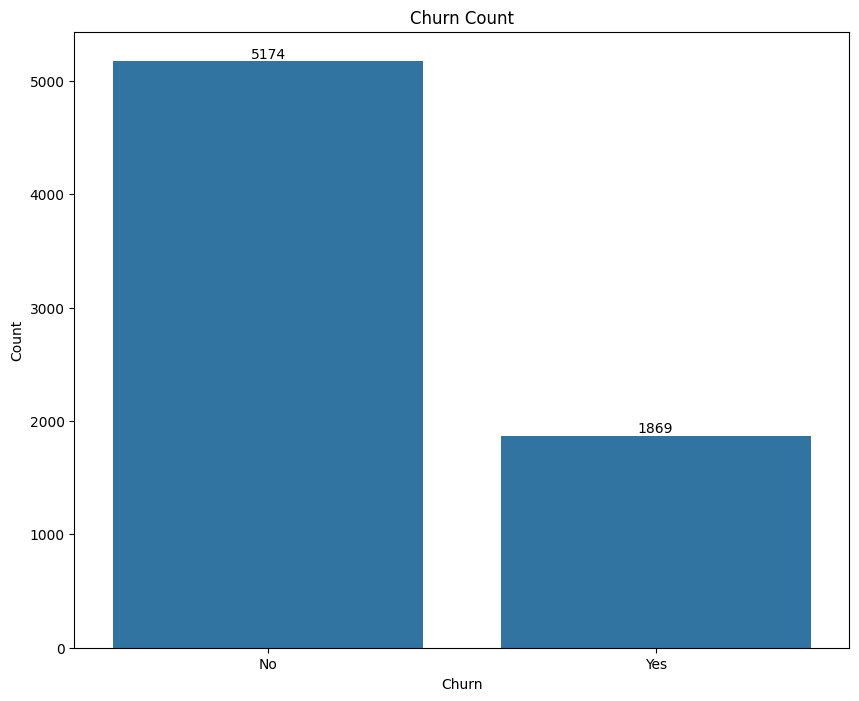

In [7]:
plt.figure(figsize=(10,8))
ax=sns.countplot(x="Churn", data=df)
for bars in ax.containers:
    ax.bar_label(bars)

plt.xlabel("Churn")
plt.ylabel("Count")
plt.title("Churn Count")
plt.show()

Observation: : most customers stayed with company while the smaller number of churned .

Business Insight : reducing the churn can help to improve  customer retention and company revenue .

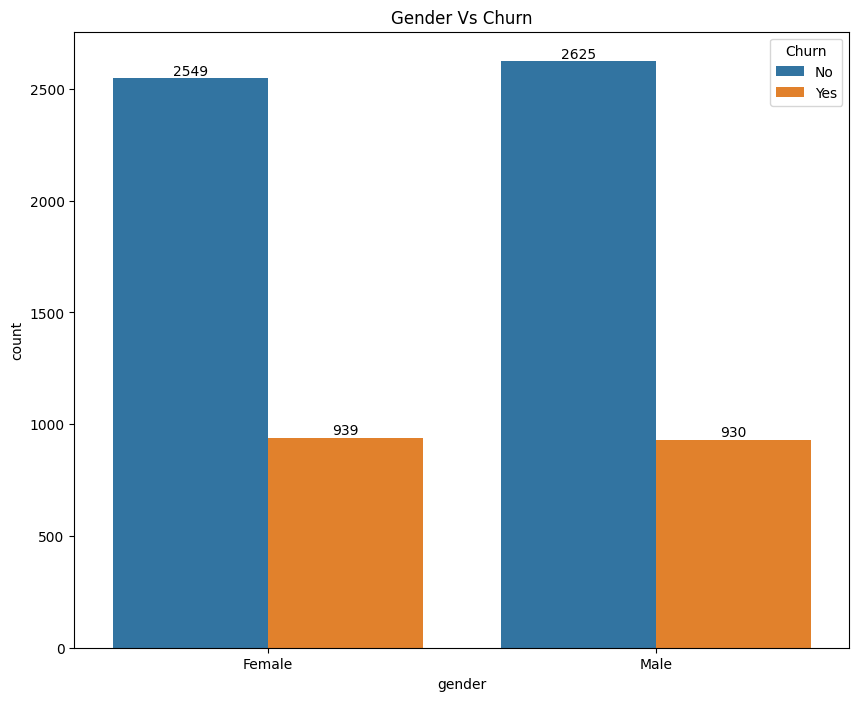

In [8]:
plt.figure(figsize=(10,8))
ax=sns.countplot(x="gender",hue="Churn",data = df)
for bars in ax.containers:
  ax.bar_label(bars)
plt.title("Gender Vs Churn")
plt.show()

Observation : females customers are more churned compare to male customers

Business Insight: female customers show a higher churn rate. the company can introduce special offers and retention programs to improve customer satisfaction and reduce customer loss.


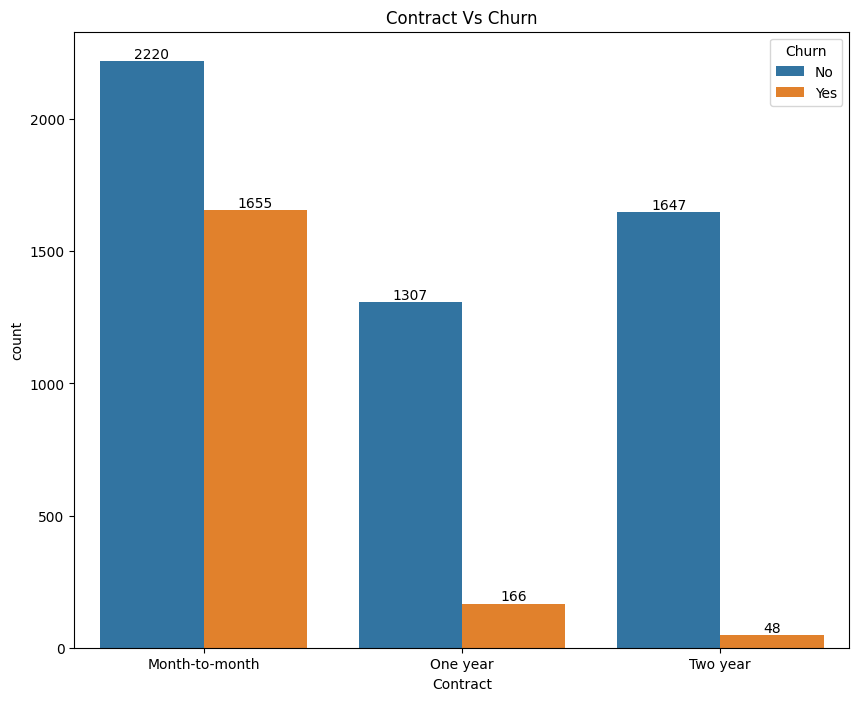

In [9]:
plt.figure(figsize=(10,8))
ax=sns.countplot(x="Contract",hue="Churn",data = df)
for bars in ax.containers:
  ax.bar_label(bars)
plt.title("Contract Vs Churn")
plt.show()

Insight : the analisys shows that
month to month churned ratio  is high ,
one year = low ,
two year = very low .

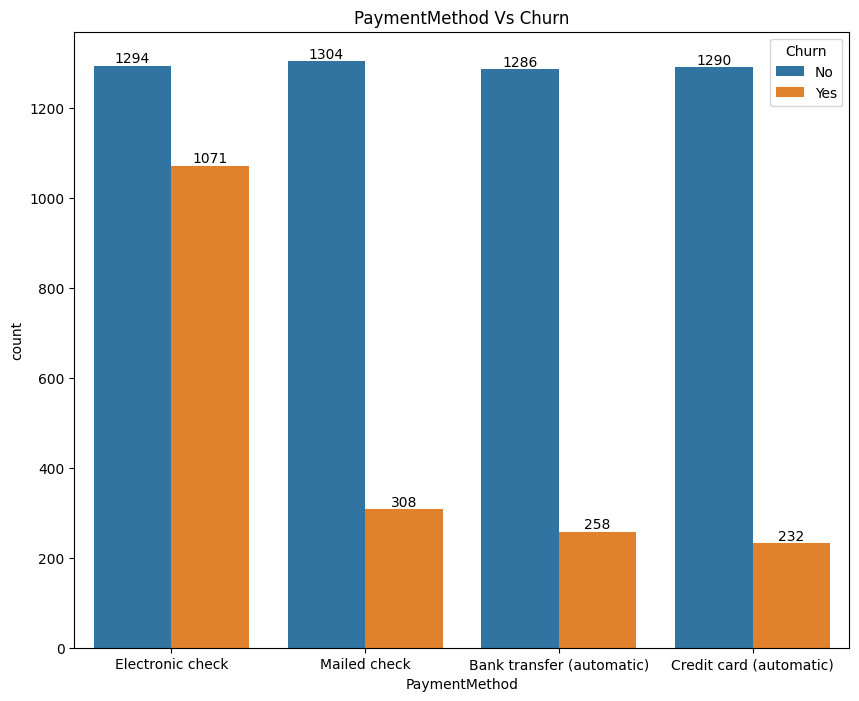

In [11]:
plt.figure(figsize=(10,8))
ax=sns.countplot(x="PaymentMethod",hue="Churn",data = df)
for bars in ax.containers:
  ax.bar_label(bars)
plt.title("PaymentMethod Vs Churn")
plt.show()

Observation : chart shows that electronic check  paymentmethod customers chur retio are higher then other paymentmethods.

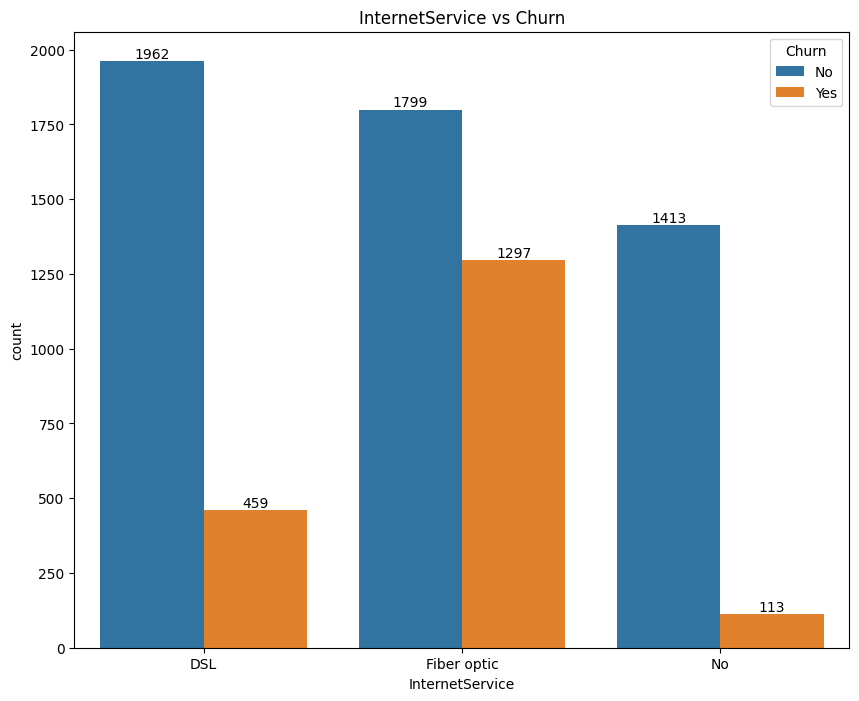

In [12]:
plt.figure(figsize=(10,8))
ax=sns.countplot(x="InternetService",hue="Churn",data=df)
for bars in ax.containers:
  ax.bar_label(bars)
plt.title("InternetService vs Churn")
plt.show()

Insight : Customers using Fiber Optic internet service show a higher churn rate compared to DSL and customers without internet service.

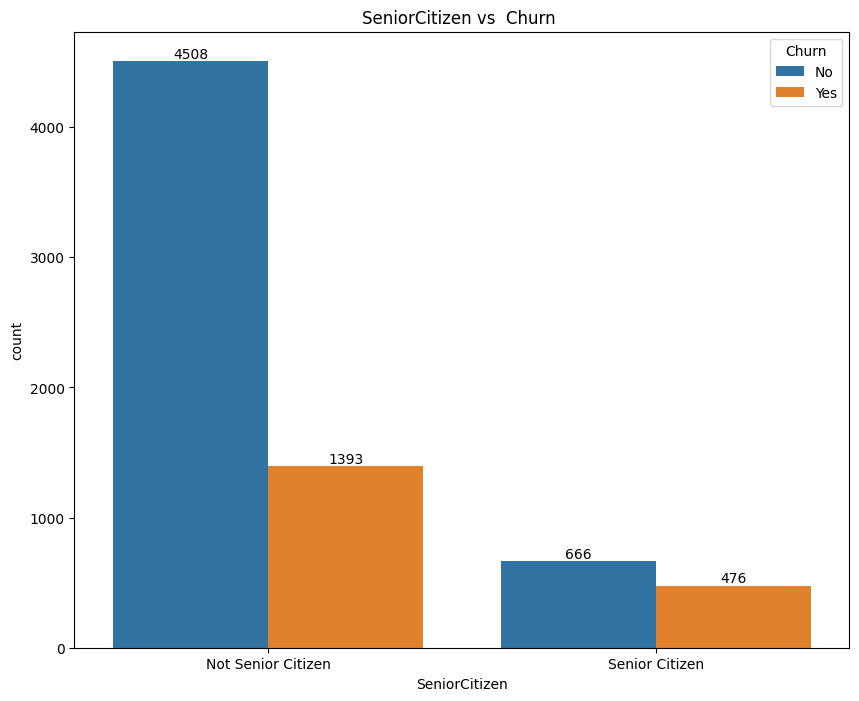

In [13]:
df['SeniorCitizen'] = df['SeniorCitizen'].replace({
    0: 'Not Senior Citizen',
    1: 'Senior Citizen'
})

plt.figure(figsize=(10,8))
ax=sns.countplot(x="SeniorCitizen",hue="Churn",data=df)
for bars in ax.containers:
  ax.bar_label(bars)
plt.title("SeniorCitizen vs  Churn ")
plt.show()

Insight : Most churned customers are not senior citizen .

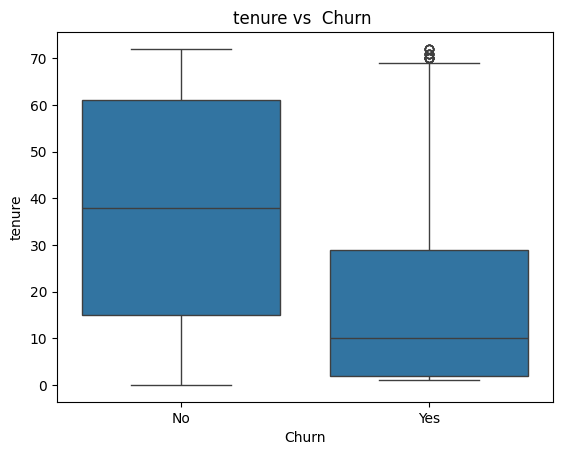

In [14]:
# plt.figure(figsize=(10,8))
ax=sns.boxplot(x="Churn",y="tenure",data=df)
plt.title("tenure vs  Churn ")
plt.show()

Insight : Customers who churned generally stayed with the company for a much shorter period compared to customers who remained .

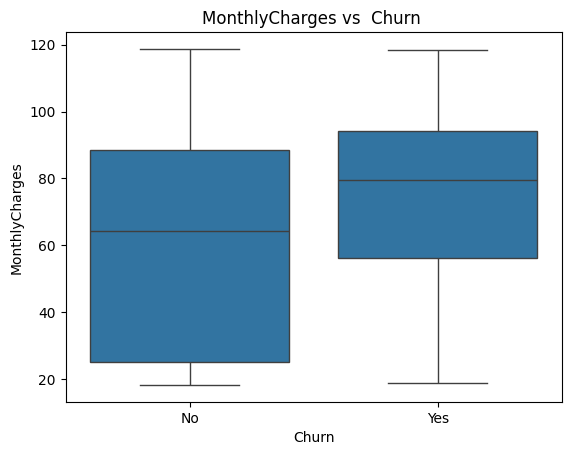

In [15]:
sns.boxplot(x="Churn",y="MonthlyCharges",data=df)
plt.title("MonthlyCharges vs  Churn ")
plt.show()

Insight :
Customers who churned tend to have higher monthly charges compared to customers who stayed with the company.

Business Insight:
Higher monthly charges may be a factor contributing to customer churn. The company can introduce personalized discounts, loyalty rewards, or affordable plans to improve customer retention and reduce customer loss.

**Feature Engineering**
converting categorical data into numerical values and selecting useful features for model training.

In [16]:
df_ml = df.copy()
df_ml.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,Not Senior Citizen,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,Not Senior Citizen,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,Not Senior Citizen,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,Not Senior Citizen,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,Not Senior Citizen,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [17]:
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()

In [18]:
for col in df_ml.columns:
  if df_ml[col].dtype == "object":
    df_ml[col] = le.fit_transform(df_ml[col])

In [28]:
df_ml = df_ml.drop('customerID', axis=1)

In [21]:
X = df_ml.drop('Churn', axis=1)
y = df_ml['Churn']

In [19]:
df.columns

Index(['customerID', 'gender', 'SeniorCitizen', 'Partner', 'Dependents',
       'tenure', 'PhoneService', 'MultipleLines', 'InternetService',
       'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport',
       'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling',
       'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'Churn'],
      dtype='object')

In [33]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

**Logistic Regression**

In [36]:
from sklearn.linear_model import LogisticRegression
lr = LogisticRegression(max_iter=5000,solver='liblinear')
lr.fit(X_train, y_train)

LogisticRegression(max_iter=5000, solver='liblinear')

In [37]:
y_pred = lr.predict(X_test)
print(y_pred)

[1 0 0 ... 0 0 0]


In [45]:
from sklearn.metrics import accuracy_score

accuracy = accuracy_score(y_test, y_pred)

print("Logistic Regression :", accuracy)

Logistic Regression : 0.8161816891412349


In [39]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred)

print(cm)

[[939  97]
 [162 211]]


In [40]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.85      0.91      0.88      1036
           1       0.69      0.57      0.62       373

    accuracy                           0.82      1409
   macro avg       0.77      0.74      0.75      1409
weighted avg       0.81      0.82      0.81      1409



**Random Forest**

In [41]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(random_state=42)

rf.fit(X_train, y_train)

rf_pred = rf.predict(X_test)

In [43]:
rf_accuracy = accuracy_score(y_test, rf_pred)

print("Random Forest Accuracy :", rf_accuracy)

Random Forest Accuracy : 0.7970191625266146


In [46]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred)

print(cm)

[[939  97]
 [162 211]]


In [47]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.85      0.91      0.88      1036
           1       0.69      0.57      0.62       373

    accuracy                           0.82      1409
   macro avg       0.77      0.74      0.75      1409
weighted avg       0.81      0.82      0.81      1409



In [44]:
print("Logistic Regression :", accuracy)
print("Random Forest :", rf_accuracy)

Logistic Regression : 0.8161816891412349
Random Forest : 0.7970191625266146


Conclusion

This project focused on predicting customer churn using machine learning techniques. After cleaning and analyzing the IBM Telco Customer Churn dataset, several important factors affecting customer churn were identified through exploratory data analysis.

Key findings include:
- Customers with month-to-month contracts are more likely to churn.
- Customers with higher monthly charges have a higher churn rate.
- New customers (low tenure) are more likely to leave the company.
- Fiber Optic customers showed a higher churn rate.
- Customers using Electronic Check payment method had higher churn.

Two machine learning models were trained and compared.

- Logistic Regression Accuracy: 81.62%
- Random Forest Accuracy: 79.70%

Logistic Regression achieved better performance on this dataset and was selected as the final model.

This project demonstrates how data analysis and machine learning can help businesses identify customers who are likely to leave and support better customer retention strategies.